In [41]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [44]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data() 

In [45]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)   
print("y_test shape:", y_test.shape)  


X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


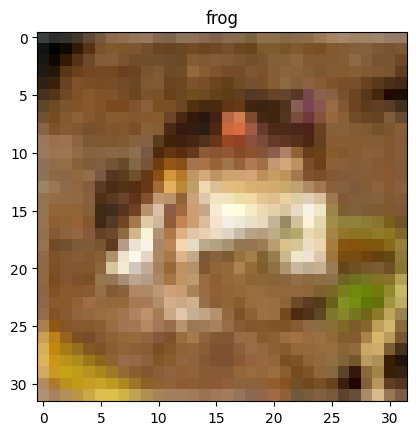

In [46]:
class_dist=["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
plt.figure()
plt.imshow(X_train[0])
plt.title(class_dist[y_train[0][0]])
plt.grid(False)
plt.show()

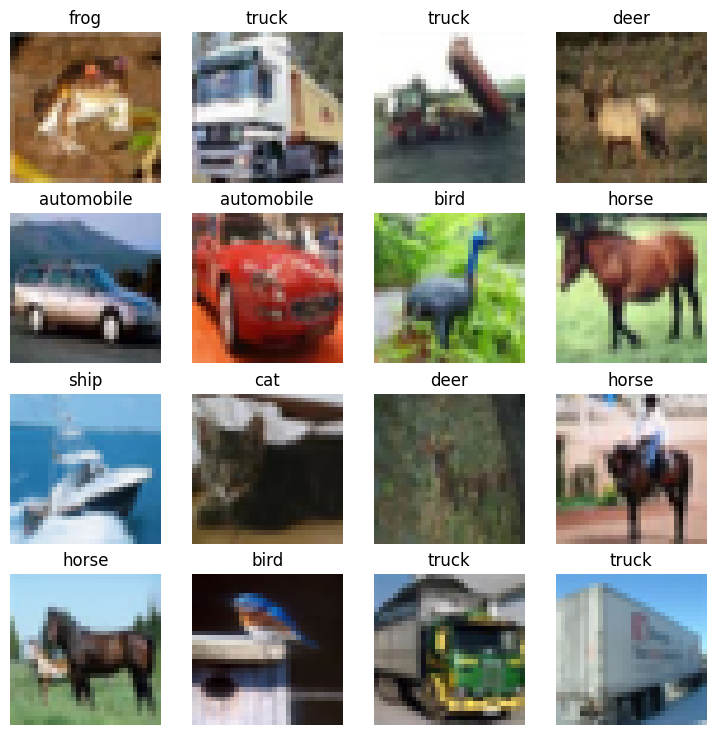

In [47]:
def fig(class_dist=["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]):
    plt.figure(figsize=(9,9))
    for i in range(16):
        plt.subplot(4,4,i+1)   
        plt.imshow(X_train[i])
        plt.title(class_dist[y_train[i][0]])
        plt.axis("off")
    plt.show()
fig()    

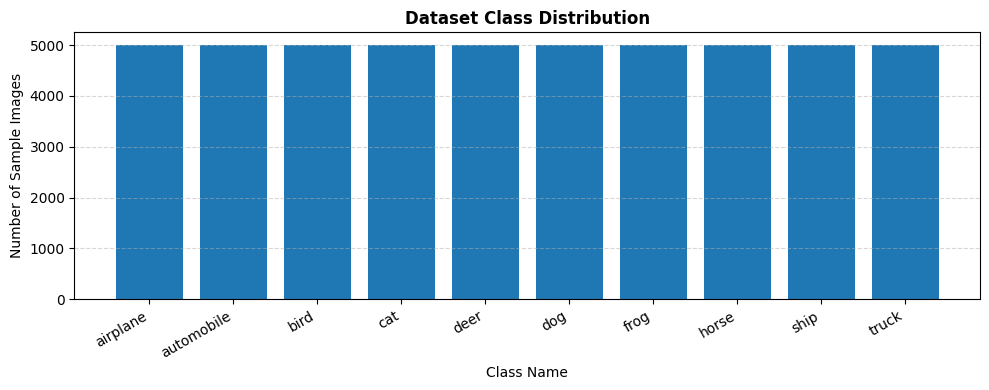

In [48]:
# 1. Flatten the 2D array to 1D for clean indexing and counting
y_train_flat = y_train.flatten()

# 2. Extract unique labels and their exact counts
unique_classes, counts = np.unique(y_train_flat, return_counts=True)

# 3. Generate the visual distribution bar chart
plt.figure(figsize=(10, 4))
plt.bar(class_dist, counts)
plt.title("Dataset Class Distribution", fontsize=12, fontweight='bold')
plt.xlabel("Class Name", fontsize=10)
plt.ylabel("Number of Sample Images", fontsize=10)
plt.xticks(rotation=30, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [49]:
print("smallest pixel:", X_train.min())
print("largest pixel:", X_train.max())

smallest pixel: 0
largest pixel: 255


Data Exploration Summary: The dataset consists of 50,000 training samples and 10,000 testing samples. Each image is a low-fidelity 32x32 pixel RGB color image. Pixel intensities range from 0 to 255, indicating scaling normalization is required. The dataset is perfectly balanced, with exactly 5,000 images per class across all 10 categories, eliminating the need for class-weighting techniques during model optimization.

# Data Preprocessing

> ****Normalization

In [50]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [51]:
print("smallest pixel:", X_train.min())
print("largest pixel:", X_train.max())

smallest pixel: 0.0
largest pixel: 1.0


>  ****Data Splitting:

In [52]:
X1_train, X_val, y1_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [53]:
print("X1_train shape:", X1_train.shape)
print("y1_train shape:", y1_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)


X1_train shape: (40000, 32, 32, 3)
y1_train shape: (40000, 1)
X_val shape: (10000, 32, 32, 3)
y_val shape: (10000, 1)


> ****Image Augmentation:

In [54]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

# Model Development

In [55]:
model = tf.keras.Sequential([
    data_augmentation,

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(10, activation="softmax")   
])

In [56]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [57]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [58]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X1_train,
    y1_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.3239 - loss: 1.8333 - val_accuracy: 0.4660 - val_loss: 1.4402
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4363 - loss: 1.5597 - val_accuracy: 0.4428 - val_loss: 1.5812
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4845 - loss: 1.4507 - val_accuracy: 0.5473 - val_loss: 1.2618
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5112 - loss: 1.3781 - val_accuracy: 0.5922 - val_loss: 1.1593
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5318 - loss: 1.3260 - val_accuracy: 0.5820 - val_loss: 1.1919
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5514 - loss: 1.2729 - val_accuracy: 0.5939 - val_loss: 1.1857
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5697 - loss: 1.2310 - val_accuracy: 0.6265 - val_loss: 1.0577
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5809 - loss: 1.2075 - val_accuracy: 0.

In [59]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# 1. Get model predictions (probabilities)
y_pred_probs = model.predict(X_test)

# 2. Convert probabilities to class integers (argmax)
y_pred = np.argmax(y_pred_probs, axis=1)
# y_test should already be class integers (if using sparse_categorical_crossentropy)
# If y_test is one-hot encoded, run: y_true = np.argmax(y_test, axis=1)

# 3. Generate the text report (Precision, Recall, F1-Score per class)
print(classification_report(y_test, y_pred))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.73      0.76      0.74      1000
           1       0.79      0.86      0.82      1000
           2       0.68      0.52      0.59      1000
           3       0.57      0.47      0.51      1000
           4       0.67      0.64      0.66      1000
           5       0.70      0.55      0.62      1000
           6       0.68      0.83      0.75      1000
           7       0.72      0.78      0.75      1000
           8       0.77      0.86      0.81      1000
           9       0.72      0.80      0.75      1000

    accuracy                           0.71     10000
   macro avg       0.70      0.71      0.70     10000
weighted avg       0.70      0.71      0.70     10000



Overall model performance: the model reaches 71% overall accuracy and a macro F1 around 0.70.

Best classes: class 1 and class 8 are strong (F1 0.82 and 0.81), showing the model can learn some visual categories well.

Weakest classes: classes 2, 3, and 5 have the lowest recall and F1 (class 3 worst at F1 0.51), indicating the model misses many true examples from these classes or confuses them with others.

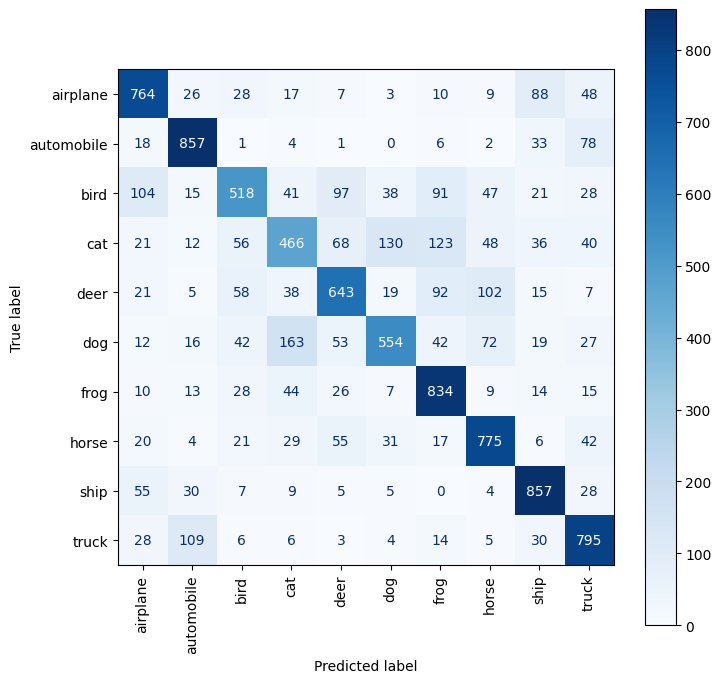

In [60]:
# 4. Generate and plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"{class_dist[i]}" for i in range(10)])

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.show()

The confusion matrix shows that the CNN correctly classified most images, as indicated by the strong diagonal values. The model achieved its best performance on automobile (857 correct predictions), ship (857), frog (834), truck (795), horse (775), and airplane (764). The greatest confusion occurred between visually similar classes, particularly dogs and cats (163 dog images misclassified as cats), cats and dogs (130 cat images misclassified as dogs), trucks and automobiles (109 truck images misclassified as automobiles), and deer and horses (102 deer images misclassified as horses). These misclassifications are expected due to the low resolution (32 × 32 pixels) of the CIFAR-10 dataset and the visual similarity among certain object categories. Overall, the confusion matrix indicates that the custom CNN learned meaningful features and achieved good classification performance while still facing challenges in distinguishing similar classes.

# Hyperparameter tuining

In [94]:
def build_model(hp):

    model = tf.keras.Sequential([
        data_augmentation,

        tf.keras.layers.Conv2D(
            filters=hp.Choice("conv1_filters", [32, 64]),
            kernel_size=(3,3),
            activation="relu"
        ),
        tf.keras.layers.MaxPooling2D((2,2)),

        tf.keras.layers.Conv2D(
            filters=hp.Choice("conv2_filters", [64, 128]),
            kernel_size=(3,3),
            activation="relu"
        ),
        tf.keras.layers.MaxPooling2D((2,2)),

        tf.keras.layers.Conv2D(
            filters=hp.Choice("conv3_filters", [128, 256]),
            kernel_size=(3,3),
            activation="relu"
        ),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(
            units=hp.Choice("dense_units", [128, 256]),
            activation="relu"
        ),

        tf.keras.layers.Dropout(
            hp.Choice("dropout", [0.1, 0.3, 0.5])
        ),

        tf.keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Choice(
                "learning_rate",
                [1e-3, 5e-4, 1e-4]
            )
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [99]:
import keras_tuner as kt

tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=30,
    directory="tuner3",
    project_name="cnn_cifar10"
)

In [100]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

tuner.search(
    X1_train,
    y1_train,
    validation_data=(X_val, y_val),
    epochs=30,
    callbacks=[early_stop]
)

Trial 30 Complete [00h 02m 01s]
val_accuracy: 0.6654000282287598

Best val_accuracy So Far: 0.7372999787330627
Total elapsed time: 01h 12m 23s


In [104]:
best_model = tuner.get_best_models(1)[0]
best_hp = tuner.get_best_hyperparameters(1)[0]

print(best_hp.values)

{'conv1_filters': 64, 'conv2_filters': 128, 'conv3_filters': 128, 'dense_units': 128, 'dropout': 0.1, 'learning_rate': 0.0005}


In [105]:
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 486,794 (1.86 MB)

 Trainable params: 486,794 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

In [109]:
best_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=best_hp.get("learning_rate")
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = best_model.fit(
    X1_train,
    y1_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7836 - loss: 0.6162 - val_accuracy: 0.7410 - val_loss: 0.8008
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7858 - loss: 0.6075 - val_accuracy: 0.7537 - val_loss: 0.7540
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7875 - loss: 0.6002 - val_accuracy: 0.7349 - val_loss: 0.8153
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7901 - loss: 0.5929 - val_accuracy: 0.7570 - val_loss: 0.7509
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7922 - loss: 0.5911 - val_accuracy: 0.7511 - val_loss: 0.7536
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7951 - loss: 0.5819 - val_accuracy: 0.7531 - val_loss: 0.7633
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7968 - loss: 0.5784 - val_accuracy: 0.7564 - val_loss: 0.7332
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7965 - loss: 0.5736 - val_accuracy: 0.

In [110]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# 1. Get model predictions (probabilities)
y_pred_probs = best_model.predict(X_test)

# 2. Convert probabilities to class integers (argmax)
y_pred = np.argmax(y_pred_probs, axis=1)
# y_test should already be class integers (if using sparse_categorical_crossentropy)
# If y_test is one-hot encoded, run: y_true = np.argmax(y_test, axis=1)

# 3. Generate the text report (Precision, Recall, F1-Score per class)
print(classification_report(y_test, y_pred))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.76      0.84      0.80      1000
           1       0.86      0.88      0.87      1000
           2       0.76      0.65      0.70      1000
           3       0.63      0.59      0.61      1000
           4       0.73      0.72      0.72      1000
           5       0.76      0.66      0.70      1000
           6       0.76      0.86      0.81      1000
           7       0.75      0.85      0.80      1000
           8       0.90      0.81      0.85      1000
           9       0.81      0.83      0.82      1000

    accuracy                           0.77     10000
   macro avg       0.77      0.77      0.77     10000
weighted avg       0.77      0.77      0.77     10000



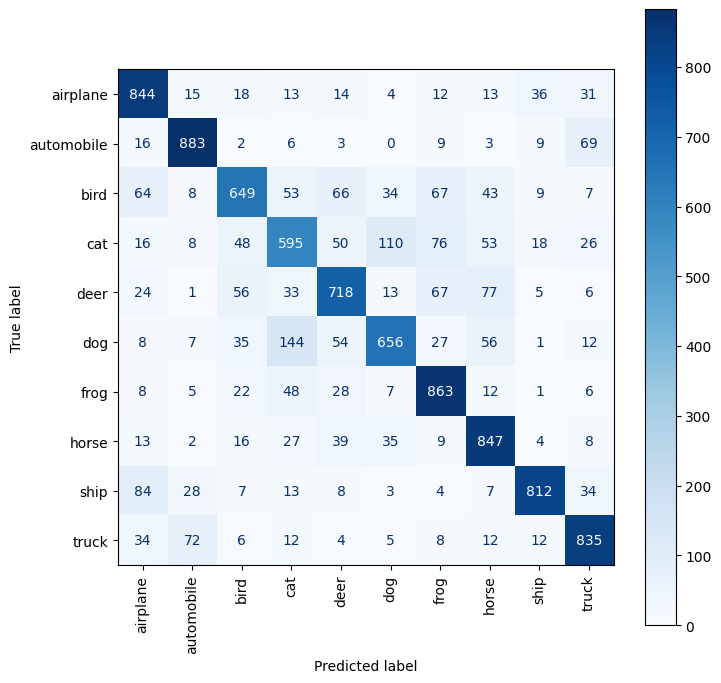

In [111]:
# 4. Generate and plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"{class_dist[i]}" for i in range(10)])

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.show()

In [112]:
best_model.save("CNN_cifar10_model.keras")